# Oxford-IIIT Pet: 初期分析

この notebook では、分類用データセットとしてダウンロードした `Oxford-IIIT Pet` を読み込み、最初に確認したい内容を整理します。

この notebook でやること:
- このデータが何のタスク向けか確認する
- `trainval` だけを使って、分類ラベルの構造を理解する
- 画像の見た目をざっくり確認する
- クラス数、画像数、画像サイズなどの簡単な統計を見る
- 前処理をどう設計するかの見通しを立てる

注意:
- 今回は **`test.txt` は読みません**
- 初期分析の段階では、`trainval.txt` だけを見て進めます


In [12]:
from __future__ import annotations

import random
import re
import xml.etree.ElementTree as ET
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
random.seed(42)
np.random.seed(42)


## 1. データの場所を確認する

このデータセットは Docker コンテナ内では `/workspace/data/oxford_iiit_pet` に置かれる想定です。

ここでは以下だけ使います。
- `images/`: 元画像
- `annotations/trainval.txt`: 学習・検証側の一覧
- `annotations/trimaps/`: 対象領域の trimap

`annotations/test.txt` は存在しても、ここでは読みません。

In [13]:
dataset_root = Path("/workspace/data/oxford_iiit_pet")
images_dir = dataset_root / "images"
annotations_dir = dataset_root / "annotations"
trimaps_dir = annotations_dir / "trimaps"
trainval_file = annotations_dir / "trainval.txt"

required_paths = [images_dir, annotations_dir, trimaps_dir, trainval_file]
missing_paths = [path for path in required_paths if not path.exists()]

if missing_paths:
    missing_text = "\n".join(str(path) for path in missing_paths)
    raise FileNotFoundError(
        "Oxford-IIIT Pet が見つかりません。先に download script を実行してください。\n"
        f"missing:\n{missing_text}"
    )

print(f"dataset_root: {dataset_root}")
print(f"images_dir exists: {images_dir.exists()}")
print(f"trainval_file exists: {trainval_file.exists()}")
print(f"trimaps_dir exists: {trimaps_dir.exists()}")


dataset_root: /workspace/data/oxford_iiit_pet
images_dir exists: True
trainval_file exists: True
trimaps_dir exists: True


## 2. `trainval.txt` を読む

`trainval.txt` の各行には、画像名とラベル情報が入っています。

今回の分類ではまず `class_id` を主ラベルとして使います。

ここで理解したいこと:
- 1 行が 1 画像に対応する
- `class_id` が分類ラベルになる
- 画像ファイル名から breed 名も取り出せる

補足:
- `species_id` や `breed_id` もありますが、最初は `class_id` を中心に見れば十分です

In [14]:
columns = ["image_stem", "class_id", "species_id", "breed_id"]
trainval_df = pd.read_csv(trainval_file, sep=" ", header=None, names=columns)

def extract_breed_name(image_stem: str) -> str:
    match = re.match(r"^(.*)_\d+$", image_stem)
    return match.group(1) if match else image_stem

trainval_df["breed_name"] = trainval_df["image_stem"].map(extract_breed_name)
trainval_df["image_path"] = trainval_df["image_stem"].map(lambda stem: images_dir / f"{stem}.jpg")
trainval_df["trimap_path"] = trainval_df["image_stem"].map(lambda stem: trimaps_dir / f"{stem}.png")

trainval_df.head()


,image_stem,class_id,species_id,breed_id,breed_name,image_path,trimap_path
0,Abyssinian_100,1,1,1,Abyssinian,/workspace/data/oxford_iiit_pet/images/Abyssin...,/workspace/data/oxford_iiit_pet/annotations/tr...
1,Abyssinian_101,1,1,1,Abyssinian,/workspace/data/oxford_iiit_pet/images/Abyssin...,/workspace/data/oxford_iiit_pet/annotations/tr...
2,Abyssinian_102,1,1,1,Abyssinian,/workspace/data/oxford_iiit_pet/images/Abyssin...,/workspace/data/oxford_iiit_pet/annotations/tr...
3,Abyssinian_103,1,1,1,Abyssinian,/workspace/data/oxford_iiit_pet/images/Abyssin...,/workspace/data/oxford_iiit_pet/annotations/tr...
4,Abyssinian_104,1,1,1,Abyssinian,/workspace/data/oxford_iiit_pet/images/Abyssin...,/workspace/data/oxford_iiit_pet/annotations/tr...


## 3. このデータセットは何のタスクか

このデータセットは、まずは **画像分類** に使えます。

分類タスクとして見ると:
- 入力: ペット画像 1 枚
- 出力: どの breed か

また、このデータセットには segmentation 用 annotation も含まれています。
ただし今は milestone2 の分類に入る段階なので、まずは分類タスクとして整理します。

In [15]:
num_images = len(trainval_df)
num_classes = trainval_df["class_id"].nunique()
num_breeds = trainval_df["breed_name"].nunique()

summary_df = pd.DataFrame(
    {
        "metric": ["num_trainval_images", "num_classes", "num_breed_names"],
        "value": [num_images, num_classes, num_breeds],
    }
)
summary_df


,metric,value
0,num_trainval_images,3680
1,num_classes,37
2,num_breed_names,37


## 4. サンプル画像を見てみる

最初にやるべきことは、ラベルより先に実際の画像を見ることです。

ここで理解したいこと:
- どんな見た目の画像が入っているか
- 背景は単純か複雑か
- 対象サイズは一定か
- 画像の質感やばらつきはどれくらいあるか

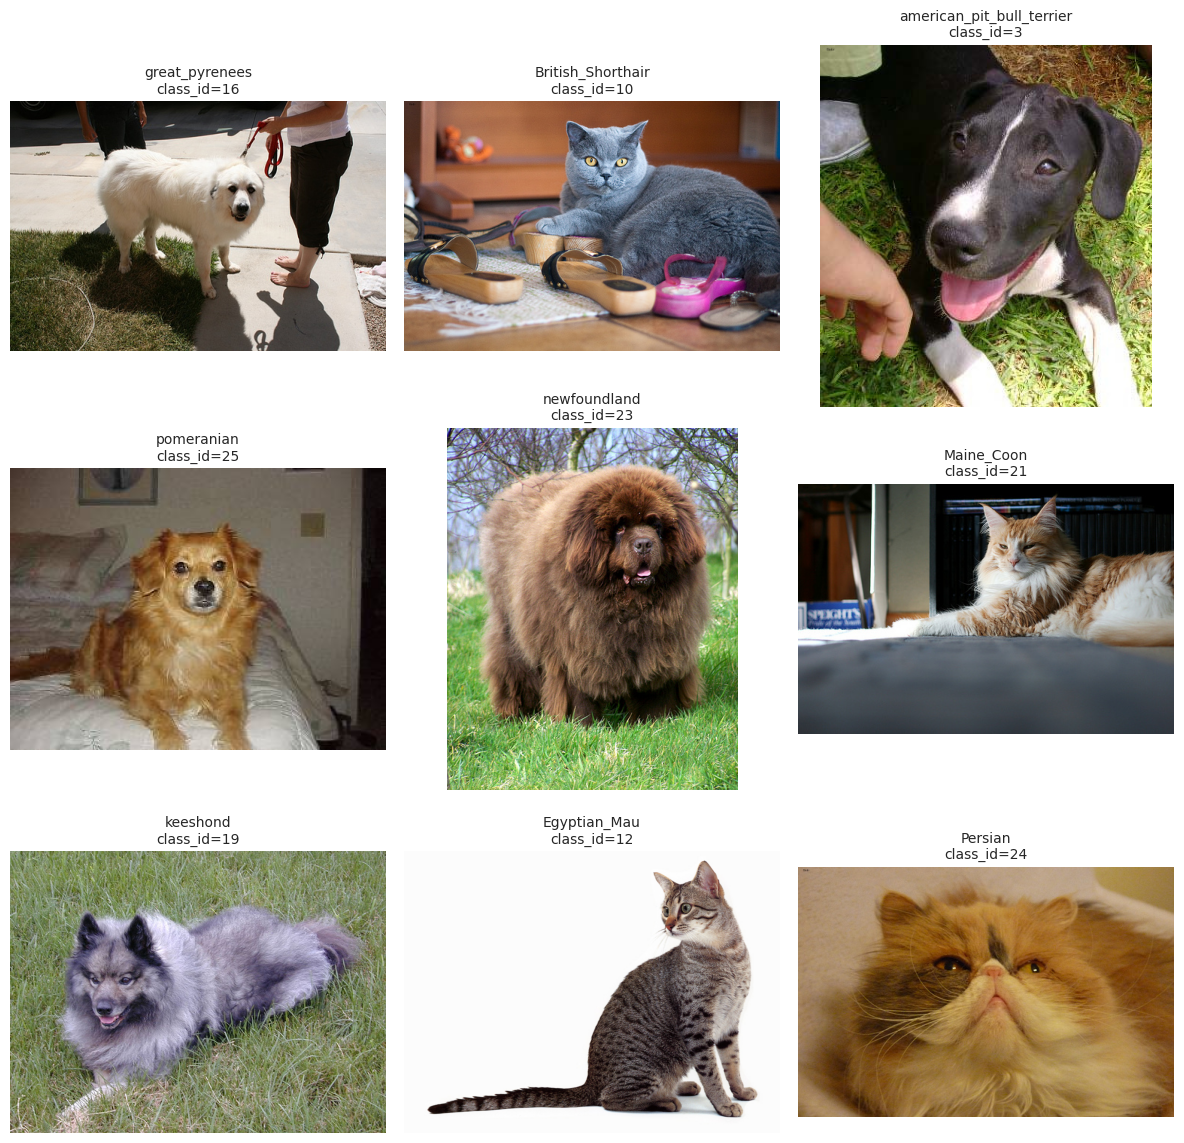

In [16]:
sample_indices = random.sample(range(len(trainval_df)), k=9)
sample_rows = trainval_df.iloc[sample_indices].reset_index(drop=True)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for ax, (_, row) in zip(axes.flat, sample_rows.iterrows()):
    image = Image.open(row["image_path"]).convert("RGB")
    ax.imshow(image)
    ax.set_title(f"{row['breed_name']}\nclass_id={row['class_id']}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()


## 5. クラス分布を見る

分類では、クラスごとの枚数差を最初に見ておくと安心です。

今回は `trainval` のみで集計します。
test 側の枚数や分布はこの段階では見ません。

In [17]:
class_counts = (
    trainval_df.groupby(["class_id", "breed_name"]).size().reset_index(name="num_images")
    .sort_values("num_images", ascending=False)
    .reset_index(drop=True)
)

class_counts.head(10)


,class_id,breed_name,num_images
0,1,Abyssinian,100
1,2,american_bulldog,100
2,3,american_pit_bull_terrier,100
3,4,basset_hound,100
4,5,beagle,100
5,6,Bengal,100
6,7,Birman,100
7,9,boxer,100
8,10,British_Shorthair,100
9,11,chihuahua,100


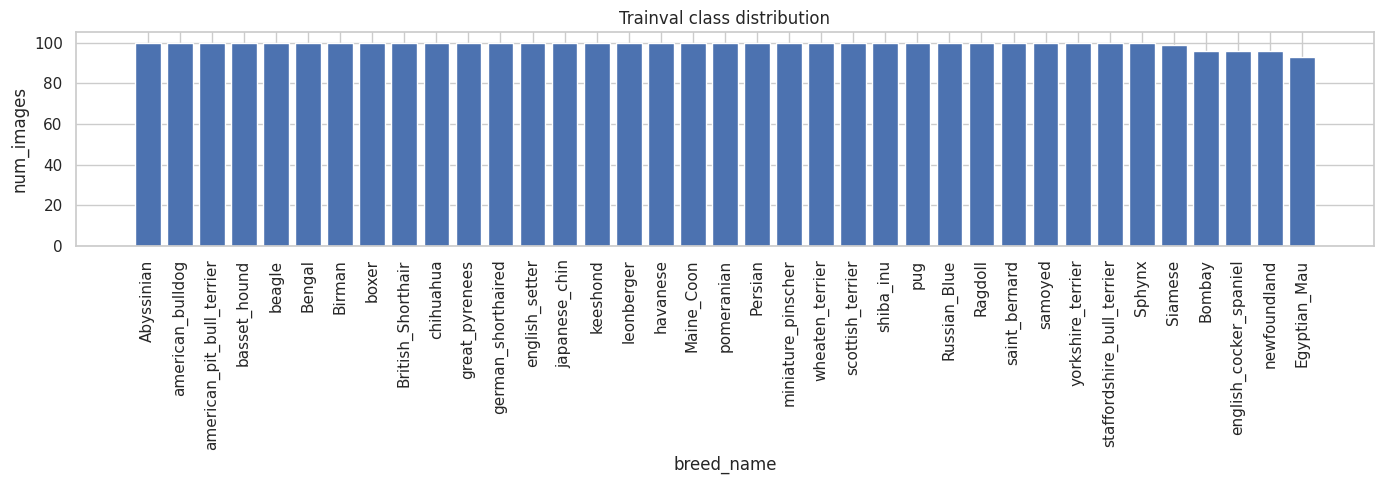

In [18]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(class_counts["breed_name"], class_counts["num_images"])
ax.set_title("Trainval class distribution")
ax.set_xlabel("breed_name")
ax.set_ylabel("num_images")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()


## 6. 画像サイズの統計を見る

分類タスクでも、画像サイズのばらつきは重要です。

ここで理解したいこと:
- 解像度が揃っているか
- 縦長 / 横長 / 正方形がどれくらいあるか
- 後で resize や crop をどう設計するべきか

In [19]:
image_size_records = []

for image_path in trainval_df["image_path"]:
    with Image.open(image_path) as image:
        width, height = image.size
    image_size_records.append(
        {
            "image_path": str(image_path),
            "width": width,
            "height": height,
            "aspect_ratio": width / height,
            "short_side": min(width, height),
            "long_side": max(width, height),
            "num_pixels": width * height,
        }
    )

image_stats_df = pd.DataFrame(image_size_records)
image_stats_df.describe().T


,count,mean,std,min,25%,50%,75%,max
width,3680.0,431.033424,126.328303,114.000,333.000,500.000000,500.000000,3.264000e+03
height,3680.0,383.420380,116.833678,108.000,333.000,375.000000,500.000000,2.606000e+03
aspect_ratio,3680.0,1.176343,0.322537,0.516,0.782,1.333333,1.461988,2.564103e+00
short_side,3680.0,344.287500,92.697299,108.000,332.000,335.000000,375.000000,2.448000e+03
long_side,3680.0,470.166304,119.268932,140.000,500.000,500.000000,500.000000,3.264000e+03
num_pixels,3680.0,171954.221467,197956.908925,15552.000,166000.000,167000.000000,187500.000000,7.990272e+06


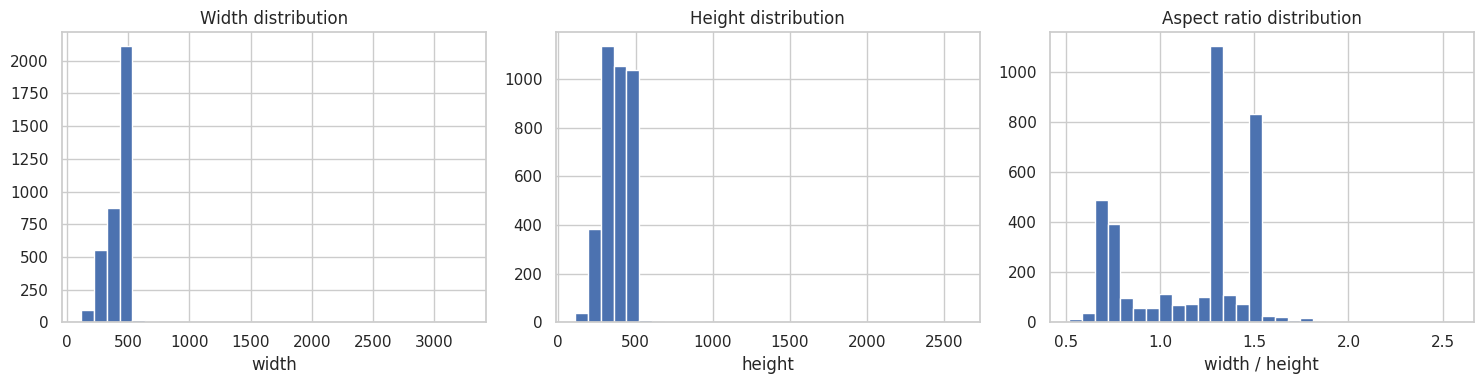

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(image_stats_df["width"], bins=30)
axes[0].set_title("Width distribution")
axes[0].set_xlabel("width")

axes[1].hist(image_stats_df["height"], bins=30)
axes[1].set_title("Height distribution")
axes[1].set_xlabel("height")

axes[2].hist(image_stats_df["aspect_ratio"], bins=30)
axes[2].set_title("Aspect ratio distribution")
axes[2].set_xlabel("width / height")

plt.tight_layout()
plt.show()


## 7. 対象の大きさと位置を見る

サイズ分布だけだと、前処理の設計はまだ弱いです。

分類で重要なのは、対象のペットが画像の中で:
- どれくらい大きく写っているか
- どれくらい中央寄りか
- 強い crop をかけても残りやすいか

ここでは trimap を使って、おおまかな対象領域を見ます。

このデータセットの trimap は:
- `1`: foreground
- `2`: background
- `3`: not classified

なので今回は **`background 以外 = pet 側の領域`** として近似します。
この近似で、分類用の前処理を考えるには十分です。

In [21]:
def compute_trimap_stats(image_path: Path, trimap_path: Path) -> dict[str, float]:
    with Image.open(image_path) as image:
        width, height = image.size

    with Image.open(trimap_path) as trimap:
        trimap_array = np.array(trimap)

    pet_mask = trimap_array != 2
    foreground_ratio = float(pet_mask.mean())

    ys, xs = np.where(pet_mask)
    if len(xs) == 0 or len(ys) == 0:
        return {
            "foreground_ratio": foreground_ratio,
            "mask_bbox_width_ratio": np.nan,
            "mask_bbox_height_ratio": np.nan,
            "mask_bbox_area_ratio": np.nan,
            "mask_center_x": np.nan,
            "mask_center_y": np.nan,
            "mask_center_offset": np.nan,
        }

    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()

    bbox_width = (x_max - x_min + 1)
    bbox_height = (y_max - y_min + 1)
    bbox_area_ratio = (bbox_width * bbox_height) / (width * height)
    center_x = ((x_min + x_max) / 2.0) / width
    center_y = ((y_min + y_max) / 2.0) / height
    center_offset = float(np.sqrt((center_x - 0.5) ** 2 + (center_y - 0.5) ** 2))

    return {
        "foreground_ratio": foreground_ratio,
        "mask_bbox_width_ratio": bbox_width / width,
        "mask_bbox_height_ratio": bbox_height / height,
        "mask_bbox_area_ratio": bbox_area_ratio,
        "mask_center_x": center_x,
        "mask_center_y": center_y,
        "mask_center_offset": center_offset,
    }

trimap_stats_records = []
for _, row in trainval_df.iterrows():
    stats = compute_trimap_stats(row["image_path"], row["trimap_path"])
    trimap_stats_records.append(stats)

trimap_stats_df = pd.DataFrame(trimap_stats_records)
analysis_df = pd.concat([trainval_df.reset_index(drop=True), image_stats_df, trimap_stats_df], axis=1)
analysis_df[[
    "foreground_ratio",
    "mask_bbox_area_ratio",
    "mask_center_offset",
]].describe().T


,count,mean,std,min,25%,50%,75%,max
foreground_ratio,3680.0,0.413609,0.177010,0.000000,0.280003,0.398570,0.534683,0.986368
mask_bbox_area_ratio,3673.0,0.694738,0.221320,0.044036,0.538326,0.728000,0.876703,1.000000
mask_center_offset,3673.0,0.080577,0.062262,0.000000,0.032256,0.068909,0.117008,0.416464


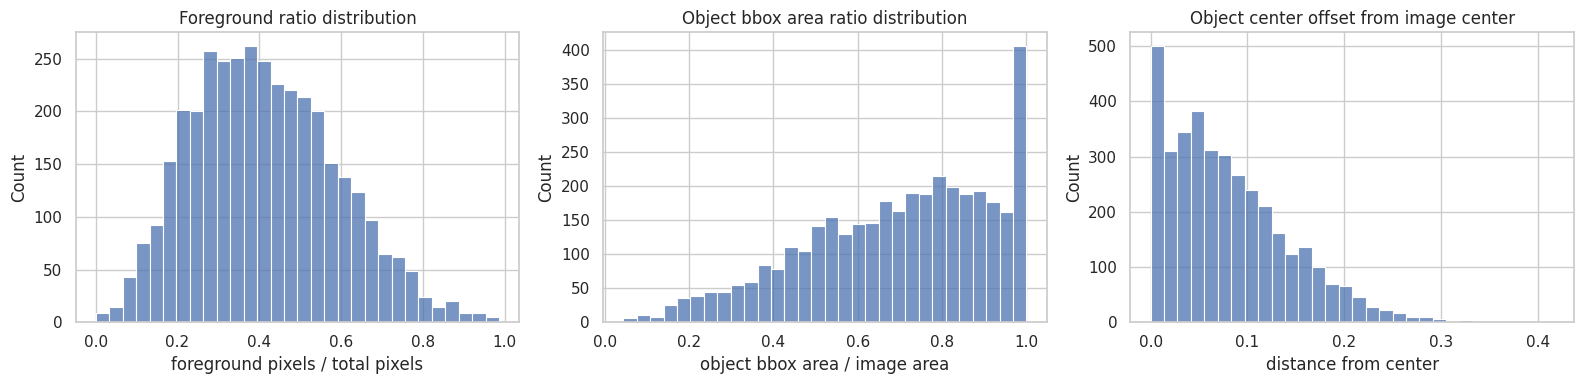

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(analysis_df["foreground_ratio"], bins=30, ax=axes[0])
axes[0].set_title("Foreground ratio distribution")
axes[0].set_xlabel("foreground pixels / total pixels")

sns.histplot(analysis_df["mask_bbox_area_ratio"], bins=30, ax=axes[1])
axes[1].set_title("Object bbox area ratio distribution")
axes[1].set_xlabel("object bbox area / image area")

sns.histplot(analysis_df["mask_center_offset"], bins=30, ax=axes[2])
axes[2].set_title("Object center offset from image center")
axes[2].set_xlabel("distance from center")

plt.tight_layout()
plt.show()


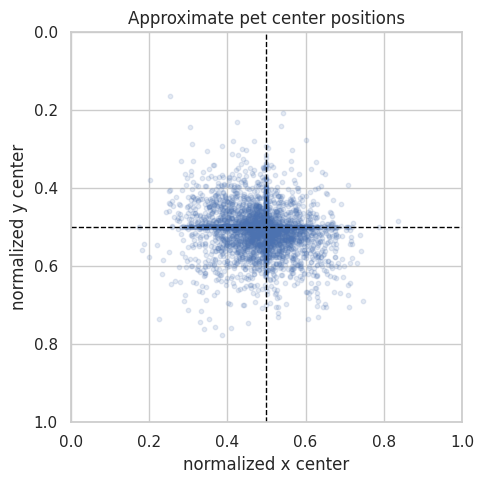

In [23]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(analysis_df["mask_center_x"], analysis_df["mask_center_y"], alpha=0.15, s=10)
ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_title("Approximate pet center positions")
ax.set_xlabel("normalized x center")
ax.set_ylabel("normalized y center")
ax.set_xlim(0, 1)
ax.set_ylim(1, 0)
plt.tight_layout()
plt.show()


## 8. 前処理の見通しを立てる

ここまでの統計から、どんな前処理が自然かを考えます。

見たい論点:
- 正方形入力にしても大きく壊れないか
- center crop を評価時に使ってよさそうか
- train 時の random crop をどれくらい強くしてよさそうか
- flip や color augmentation が効きそうか

In [24]:
preprocess_summary = pd.DataFrame(
    {
        "metric": [
            "median_width",
            "median_height",
            "median_aspect_ratio",
            "p10_aspect_ratio",
            "p90_aspect_ratio",
            "median_foreground_ratio",
            "median_mask_bbox_area_ratio",
            "median_center_offset",
            "share_center_offset_le_0.10",
            "share_center_offset_le_0.15",
        ],
        "value": [
            float(analysis_df["width"].median()),
            float(analysis_df["height"].median()),
            float(analysis_df["aspect_ratio"].median()),
            float(analysis_df["aspect_ratio"].quantile(0.10)),
            float(analysis_df["aspect_ratio"].quantile(0.90)),
            float(analysis_df["foreground_ratio"].median()),
            float(analysis_df["mask_bbox_area_ratio"].median()),
            float(analysis_df["mask_center_offset"].median()),
            float((analysis_df["mask_center_offset"] <= 0.10).mean()),
            float((analysis_df["mask_center_offset"] <= 0.15).mean()),
        ],
    }
)
preprocess_summary


,metric,value
0,median_width,500.000000
1,median_height,375.000000
2,median_aspect_ratio,1.333333
3,p10_aspect_ratio,0.668000
4,p90_aspect_ratio,1.501502
5,median_foreground_ratio,0.398570
6,median_mask_bbox_area_ratio,0.728000
7,median_center_offset,0.068909
8,share_center_offset_le_0.10,0.672554
9,share_center_offset_le_0.15,0.847283


In [25]:
recommendations = [
    "1. 正方形入力は使ってよい。縦横比のばらつきはあるが、分類モデル側では 224x224 や 256x256 へそろえる設計が自然。",
    "2. 評価時は `Resize -> CenterCrop -> Normalize` を baseline にしてよい。対象は比較的中央寄りで、center crop が極端に危険なデータではない。",
    "3. 学習時の crop は強すぎない方がよい。pet 自体は比較的大きいが、細長い画像や端寄りの例もあるので `RandomResizedCrop` の scale は保守的に始める。",
    "4. 左右反転は有効候補。猫・犬 breed 分類では左右反転で意味が壊れにくい。",
    "5. 色変化や軽い blur は有効候補。背景や撮影条件のばらつきがあるため、軽い color augmentation は試す価値がある。",
    "6. まずの共通前処理としては、train: `RandomResizedCrop(224) + HorizontalFlip + light ColorJitter + Normalize`、eval: `Resize(256) + CenterCrop(224) + Normalize` が自然。",
]

for line in recommendations:
    print(line)


1. 正方形入力は使ってよい。縦横比のばらつきはあるが、分類モデル側では 224x224 や 256x256 へそろえる設計が自然。
2. 評価時は `Resize -> CenterCrop -> Normalize` を baseline にしてよい。対象は比較的中央寄りで、center crop が極端に危険なデータではない。
3. 学習時の crop は強すぎない方がよい。pet 自体は比較的大きいが、細長い画像や端寄りの例もあるので `RandomResizedCrop` の scale は保守的に始める。
4. 左右反転は有効候補。猫・犬 breed 分類では左右反転で意味が壊れにくい。
5. 色変化や軽い blur は有効候補。背景や撮影条件のばらつきがあるため、軽い color augmentation は試す価値がある。
6. まずの共通前処理としては、train: `RandomResizedCrop(224) + HorizontalFlip + light ColorJitter + Normalize`、eval: `Resize(256) + CenterCrop(224) + Normalize` が自然。


## 9. 初期分析メモ

ここまでで、分類の入口として最低限見ておきたいことと、前処理の方向性は確認できました。

次にやることの候補:
- `train / validation` の分け方を整理する
- 共通前処理を `.py` に切り出す
- 学習ループと評価ループも共通化する
- その上で `ConvNeXt V2` や `OpenCLIP` を比較しやすくする

重要:
- 今回は test データを見ていない
- 初期分析の段階では、このまま進めてよい